
# Security and Privacy (CC2009) - 25/26
## ASSIGNMENT #1: Performance Benchmarking of Cryptographic Mechanisms
## PL1 - Elements: Amanda Lucas (202400455), Aly Filho (202401045) e Sílvia Pinto (202405988)


#### A. Generate random text files with the following sizes: 8, 64, 512, 4096, 32768, 262144, 2097152:
  &emsp;Done in ../03 - data<br>
  &emsp;We use the **urandom** from **OS** (Python) to generate random files; can be seen in **../02 - scripts/gen_files.py**

In [7]:
import os                                                            # For navegation in the file folders.
import secrets                                                       # To use entropy for true randomness.
from aes_ctr import *                                                # Auxiliar functions for the AES.
from RSA_and_SHA import *                                              # Auxiliar functions for the RSA.
from cryptography.hazmat.primitives.ciphers import Cipher            # To create a cipher for the AES.
from cryptography.hazmat.primitives.ciphers import algorithms, modes # To define the algorithm and mode of our cipher.
from cryptography.hazmat.primitives.asymmetric import rsa            # Generating keys.
from cryptography.hazmat.primitives import hashes                    # Function H(n, r).

#### B. Encrypt and decrypt random files with AES in Counter Mode, using the code that you wrote previously:
&emsp;First thing is to define 2 functions, one to encrypt and another one to decrypt, using the cryptography library from python: We will use Cipher to define a cipher with AES algorithms from algorithms in CTR mode from modes. That can been seen in **../01 - source/aes_ctr.py**<br>
&emsp;Here function 1 receives m (plaintext), the key and the nonce. It returns c (ciphertext). The function 2 receives c (ciphertext), the key and the nonce and returns the original text m (plaintext):

In [8]:
def my_encrypt_aes_ctr(plaintext, key, nonce):
    alg = algorithms.AES(key)                                        # Defines algorithm as AES
    mode = modes.CTR(nonce)                                          # Uses nonce for CTR mode
    cypher = Cipher(alg,mode)                                        # Creates cipher
    encrypt = cypher.encryptor()  
    return encrypt.update(plaintext) + encrypt.finalize() 

def my_decrypt_aes_ctr(ciphertext, key, nonce):
    alg = algorithms.AES(key) 
    mode = modes.CTR(nonce) 
    cypher = Cipher(alg,mode) 
    decrypt = cypher.decryptor()
    return decrypt.update(ciphertext) + decrypt.finalize()

&emsp;To ensure statistical significance, we automated the benchmarking process using **Pandas** and **NumPy**. We performed repeated executions over the same files to observe temporal variance, and across multiple randomly generated files of fixed sizes to evaluate the algorithm's consistency regardless of the input data. For intuitive graphical analysis we use **Matplotlib** and **Seaborn** libraries.

In [9]:
key = os.urandom(32)                                                 # Defining the key for our AES encryption
nonce = os.urandom(16)                                               # Defining the nonce

SCRIPT_DIR = os.path.dirname(os.path.abspath(os.getcwd()))           # Finds the folder where our project is stored
base_path = os.path.join(SCRIPT_DIR, "03 - data", "inputs by size")  # Builds the path to the data folder starting from the current folder
sizes = ["8", "64", "512", "4096", "32768", "262144", "2097152"]     # All file sizes available
repetitions = 30                                                     # According to central limit theory

results = AES_execution(base_path, sizes, repetitions, key, nonce)   # Executes file encryption and desencryption
df_AES = create_dataframe_AES(results)                               # Creates a dataframe of the results

##### Question B.1) Do results change if you run a fixed algorithm over the same file multiple times?

&emsp;Here we are fixing the algorithm over one unique file; that can be seen in function **plot_variation_same_file** in **plot_functions.py**, and we encrypt and decrypt this fixed file various times.<br>
&emsp;To ensure statistical significance, we chose a sample size of **n = 30** repetitions for each cryptographic operation. According to the Central Limit Theorem, a sample size of 30 is sufficient to approximate a normal distribution, allowing for reliable calculations of the standard deviation and confidence intervals.

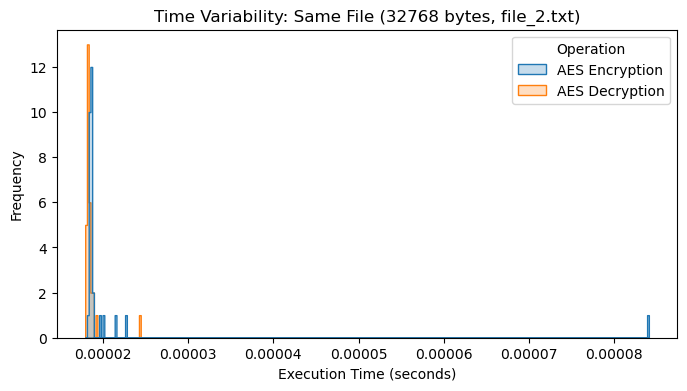

In [10]:
plot_variation_same_file(df_AES, 32768, 'file_2.txt')                # Function available in file plot_functions.py

&emsp;For a better analysis, let's take a look at the performance of a 32768 Bytes size file (the intermediary size) - but it can be done with any file size, by just calling the function with the desired size as the parameter. Studying these graphics, we can conclude:
- **Yes, the results change if you run a fixed algorithm over the same file multiple times.** That may seen strange because the AES-CTR is a deterministic algorithm, that is, the same input generates the same output with the same calculations. So, why do the times change in the 30 tests of encrypt and decrypt? That's not the algorithm's fault; the variation occurs because of the computational environment, e.g. the O.S. is doing many things at the same time and, while the Python script is working, other procedures are happening which can cause noise in our data  (called CPU jitter). In the graphics we can notice:
    1) The big bar: Shows the real and pure time of algorithm, in almost all tests (28 or 29 times). This is the execution time of our algorithm practically without any system noise.
    2) The little bars: They are outliers, and show that sometimes the OS parallels procedures which can "dirty" the data times.

&emsp;Now let's analyze the time variability for each one of the 7 defined file sizes:

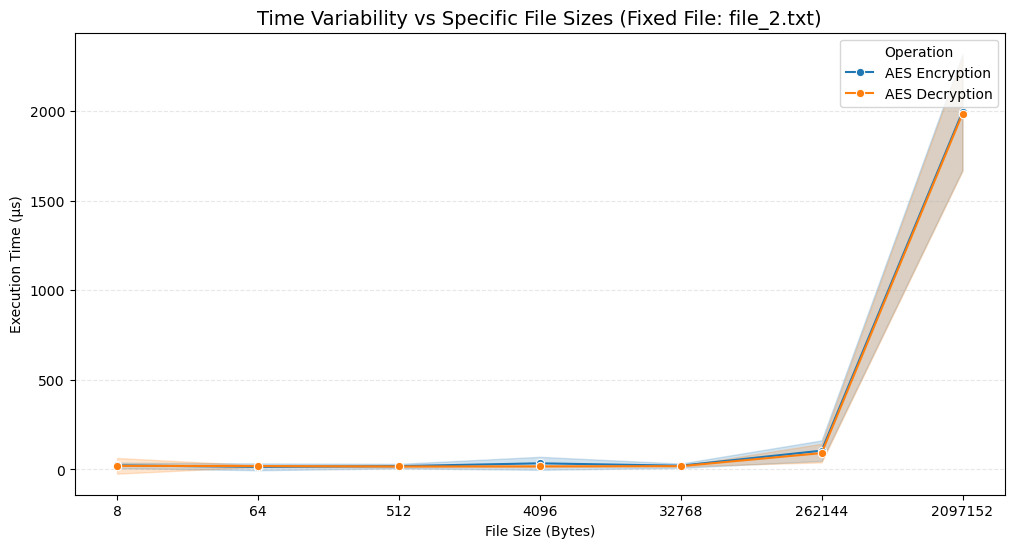

In [11]:
plot_variation_fixed_file_categorical(df_AES,'file_2.txt')           # Function available in file plot_functions.py

&emsp;The performance benchmarking of AES-256 in Counter Mode (CTR) demonstrates a clear linear correlation between file size and execution time, confirming the algorithm's O(n) efficiency. While the curves for encryption and decryption are theoretically symmetric, the increased standard deviation (shaded area) observed at the 2,097,152-byte mark highlights the impact of environmental noise and CPU jitter on larger workloads. Despite using a deterministic algorithm and a fixed file (file_2.txt), the measured variability across 30 iterations proves that execution times are susceptible to OS-level scheduling and memory latency, which become more pronounced as the processing window expands.

##### Question B.2) And what if you run an algorithm over multiple randomly generated files of fixed size?

&emsp;Now we're comparing the algorithm performance in 10 different random files. That can be seen in function **plot_comparison_fixed_size** in plot_functions.py file

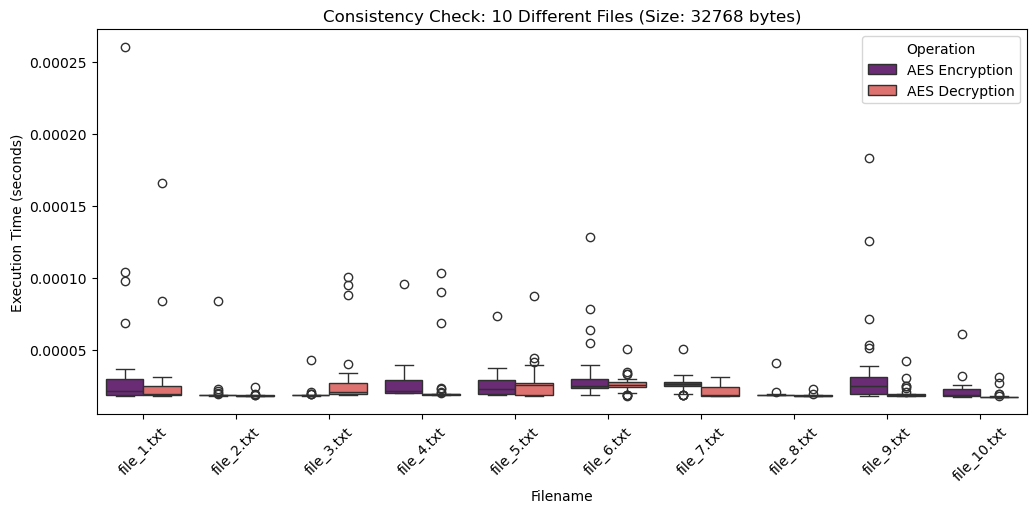

In [12]:
plot_comparison_fixed_size(df_AES,32768)                             # Function available in file plot_functions.py

&emsp; We're looking at the 262144 Bytes size, but it can be done with any file size by just calling the function with the desired size as a parameter. Studying these graphics, we can conclude:
- **No, the algorithmic execution time does not change based on the file's content.** Any variations observed between different files of the same size are purely the result of the environmental noise (CPU jitter) already proven in Question B.1, not a change in the algorithm's complexity.<br>
- Because AES in Counter Mode (AES-CTR) operates on raw byte blocks, it is completely blind to the actual content (data entropy) of the files. Encrypting a 32 KB file of structured text requires the exact same number of mathematical operations as encrypting a 32 KB file of random noise. Therefore, while the measured time fluctuates due to OS background tasks (as seen in the spikes of file_8 for 32 KB or file_1 for 2 MB), the theoretical and practical computational workload of the algorithm remains perfectly constant.

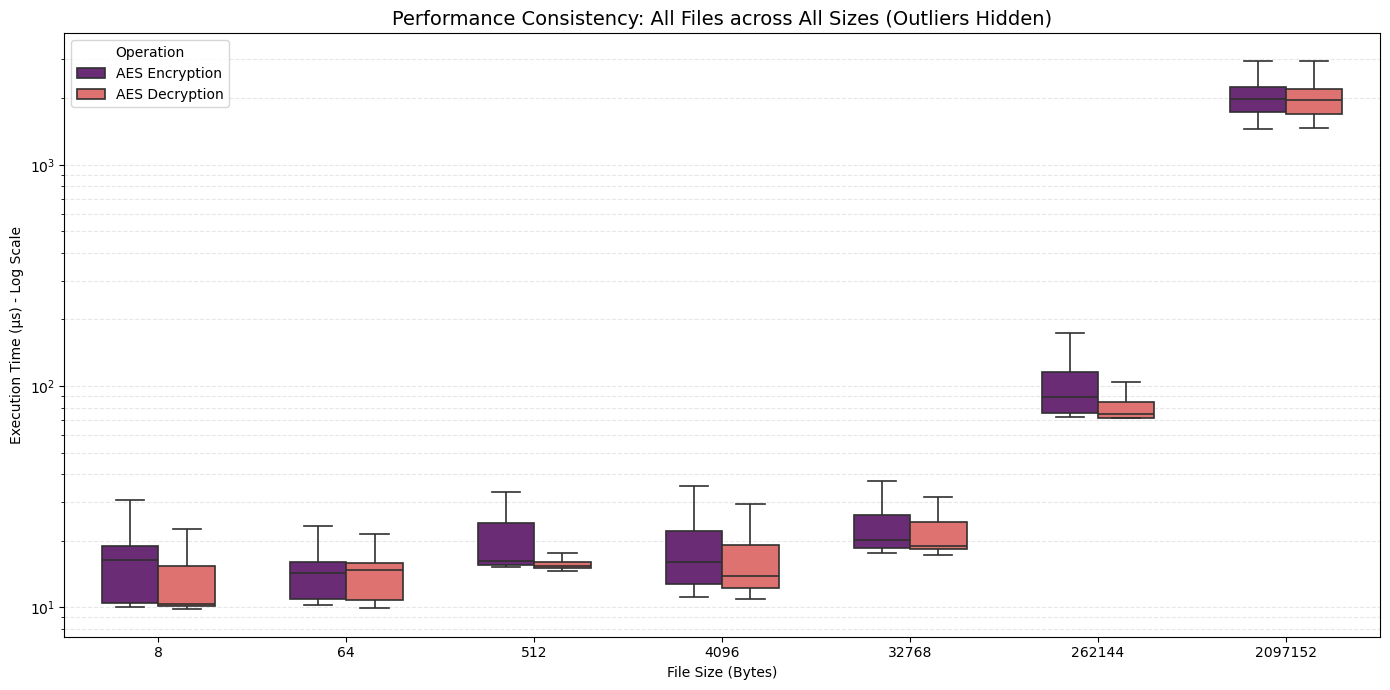

In [13]:
plot_consistency_all_sizes_us(df_AES)                                # Function available in file plot_functions.py

&emsp;This plot serves as the primary evidence for statistical significance and performance consistency across the entire dataset. By aggregating all 10 random files per size into a single categorical view, it demonstrates that AES-CTR execution time is strictly dependent on the input size (O(n)) and independent of the specific data content, as shown by the aligned medians across the 7-byte size groups. The use of a logarithmic scale on the Y-axis is crucial to visualize the full range of measurements from 8 B to 2 MB simultaneously, while the hidden outliers (achieved via showfliers=False) clarify the core distribution, proving that despite environmental jitter, the algorithm maintains a highly stable and symmetric performance profile for both encryption and decryption.

##### Final Analysis - Cross-size graphic:
For the end of the AES-CTR analysis, let's put all performances times by file size side by side in a log scale graphic (using the mean of the 30 iterations in each 10 files of each byte size):

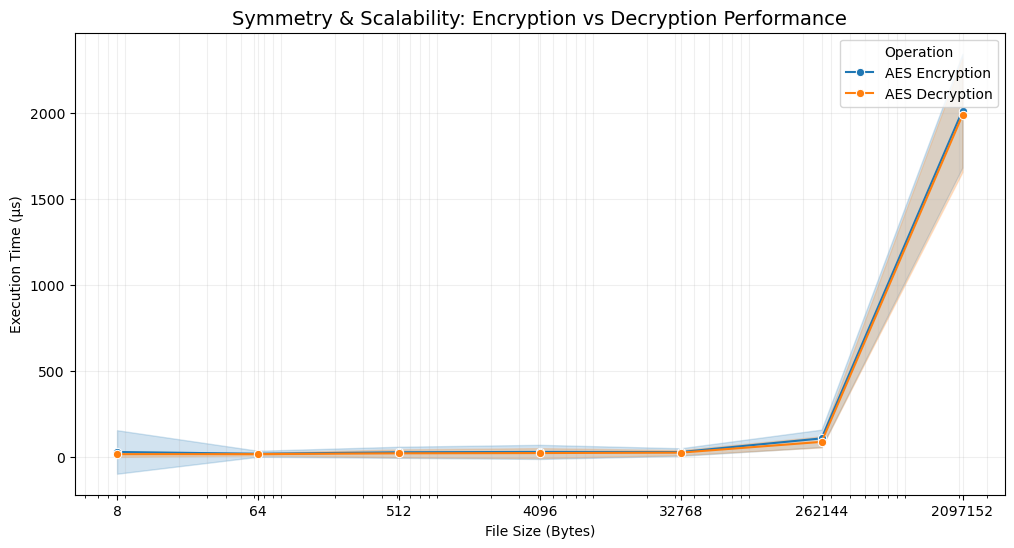

In [14]:
plot_final_scalability(df_AES)                                       # Function available in file plot_functions.py

&emsp;Studying this graphic, we can conclude:
1) **Algorithmic Symmetry:** The near-perfect overlap of the encryption (blue) and decryption (orange) plot lines demonstrates the symmetric workload of the AES Counter Mode. Because both operations simply generate a keystream (Key + Nonce) and apply an XOR bitwise operation against the payload, they are computationally indistinguishable and require the exact same execution time.
2) **Linear Time Complexity O(n):** While the plot visually resembles an exponential curve, it is plotted against a logarithmic X-axis. Mathematically, a straight linear progression plotted on a logarithmic scale produces this exact curve. This empirically proves that AES-CTR scales linearly **O(n)**: the execution time grows in direct, steady proportion to the input byte size, without exponential performance degradation.
3) **Variance Expansion:** The shaded confidence intervals (representing standard deviation across the n=30 sample size) visually widen as the file size increases. This corroborates our earlier findings: larger files demand longer execution windows and memory fetches (RAM), exponentially increasing the likelihood of Operating System interruptions, which causes the execution times to fluctuate more broadly than with smaller payloads.


---

#### C. Implementation of the RSA function and its inverse + D. SHA 256 Hash Generation

&emsp;We start by creating the functions that will mask and unmask our private key. For the encryption, we use the formula:<br>
&emsp;&emsp;**Enc(public_key, r_int) = r_int ^ e (mod n)**, where e is the exponent and n is the public number.<br>

&emsp;And, for the inverse function that decrypts, we use the formula: <br>
&emsp;&emsp;**Dec(private_key, c_r) = c_r ^ d (mod n)**, where d is the number such that e * d (mod v) = 1

In [15]:
def rsa_trapdoor_permutation(arguments):                             # Pure RSA.
    public_key, r_int = arguments[0], arguments[1]
    e = public_key.public_numbers().e
    n = public_key.public_numbers().n
    return pow(r_int, e, n)

def rsa_inverse_trapdoor(arguments):                                 # Inverse function of the one above.
    private_key, c_r = arguments[0], arguments[1]
    d = private_key.private_numbers().d
    n = private_key.private_numbers().public_numbers.n
    return pow(c_r, d, n)

&emsp;Having the RSA functions ready, we can now define a way to encrypt and decrypt a message.

For encryption:<br>
&emsp;1. Apply the trapdoor permutation to encrypt.<br>
&emsp;2. Transform r from bits to bytes, so that we can apply SHA 256 on it.<br>

For decryption:<br>
&emsp;3. Apply the inverse of the trapdoor permutation to decrypt.<br>
&emsp;4. Transform decrypted r from bits to bytes.<br>

Both operations:<br>
&emsp;5. Divide message into blocks of 32 bytes.<br>
&emsp;6. Hash each block, measuring the hashing time.<br>
&emsp;7. Add the resulting text block to our group of blocks, applying an XOR with the original block.<br>

In [16]:
def custom_encrypt_decrypt(private_key, public_key, message, mode, r):
    l_size = 32                                                      # SHA 256 output size.
    ciphertext_blocks = []    
    if (mode == "Encrypting"):  
        enc_message = message
        rsa_time, rsa_r = measure_performance_time(rsa_trapdoor_permutation, [public_key, r])
        rsa_r_bytes = rsa_r.to_bytes(256, 'big')                     # STEP 2.1.: Transform encrypted r from bits into bytes (2048 bits = 256 bytes).
        ciphertext_blocks += [rsa_r_bytes]     
        r_bytes = r.to_bytes(256, 'big')                             # STEP 2.2.: Transform original r from bits into bytes, to use in hashing operation.

    elif (mode == "Decrypting"):
        c_r = int.from_bytes(message[:256], 'big')
        rsa_time, int_r = measure_performance_time(rsa_inverse_trapdoor, [private_key, c_r])
        r_bytes = int_r.to_bytes(256, 'big')                         # STEP 4.: Transform the decrypted r from bits to bytes.
        enc_message = message[256:]

    hash_time = 0
    for i in range(0, len(enc_message), l_size):                
        block_index = i // l_size
        chunk = enc_message[i : i + l_size]                          # STEP 5.: Divide our message into blocks of 32 bytes.
        
        digest = hashes.Hash(hashes.SHA256())              
                                                                     # STEP 6.: Hash each block, measuring the hashing time.
        hash_update_time = measure_performance_time(digest.update, block_index.to_bytes(4, 'big') + r_bytes)[0]
        hash_finalize_time, block_with_hash = measure_performance_time(digest.finalize)
        hash_time += hash_update_time + hash_finalize_time
        ciphertext_blocks.append(xor_bytes(chunk, block_with_hash))  # STEP 7.: Apply XOR between original block and hashed block, and append to result block.

    return b"".join(ciphertext_blocks), hash_time, rsa_time          # Return the full resulting message and the time measurements, for future performance analysis.

&emsp;Now, we simply need to generate the private key and its corresponding public key, to perform encryption and decryption.

In [17]:
private_key = rsa.generate_private_key(public_exponent=65537, key_size=2048)
public_key = private_key.public_key()
n = public_key.public_numbers().n                                    # STEP 1.: Get public number n to generate r.
r = secrets.randbelow(n)                                             # STEP 2.: Randomize a number r to be encrypted.

&emsp;The main function processes all the files of a given size, either decrypting or encrypting them. It also registers the time measurements for each file and returns them.

In [18]:
def main(mode, base_dir, file_size):
    all_files, folder_path = get_files(base_dir, file_size, mode)    # Get 10 files for the current size andthe path of their parent folder.
    total_time = 0
    rsa_times = []
    hash_times = []
    for file_name in all_files:                                      # For each of the files, perform encryption or decryption.
        file_path = os.path.join(folder_path, file_name)

        with open(file_path, "rb") as f: 
            data = f.read()

        ciphertext, hash_time, rsa_time = custom_encrypt_decrypt(private_key, public_key, data, mode, r)
        rsa_times += [rsa_time]
        hash_times += [hash_time]
        total_time += rsa_time                                                     
                                                                     # Save the encrypted files in a new folder.        
        save_in_results(ciphertext, base_dir, file_size, file_name, mode)
    return rsa_times, hash_times                                     # Return the RSA and SHA 256 execution times for each file.

&emsp;We are ready to process our files. Starting from our base directory, we encrypt and decrypt each of the 10 files for all the available sizes, using RSA encryption and SHA 256 hashing. <br>
&emsp;To visualize and study our results, we create a database with the time measurements by file size and operation type.

In [19]:
base_dir = os.getcwd()                                               # We start from our current directory and work our way to the location of the files.
sizes = ["8", "64", "512", "4096", "32768", "262144", "2097152"]
results = {size: {} for size in sizes}

for size in sizes:
        for i in range(0,10):
            rsa_enc, hash_enc = main("Encrypting", base_dir, size)
            rsa_dec, hash_dec = main("Decrypting", base_dir, size)
            results[size][i] = {'RSA Encryption': rsa_enc[i], "Hash Encryption": hash_enc[i], 'RSA Decryption': rsa_dec[i], "Hash Decryption": hash_dec[i]}
        
df_data = create_dataframe_RSA(results)                              # For creating the dataframe.
df_data.head(10)                                                     # Showing the first 10 rows of the dataframe for a better understanding of its structure.    

,Size_Bytes,Filename,Execution_Time,Operation
0,8,file_1.txt,0.000326,RSA Encryption
1,8,file_1.txt,0.000029,Hash Encryption
2,8,file_1.txt,0.036304,RSA Decryption
3,8,file_1.txt,0.000013,Hash Decryption
4,8,file_2.txt,0.000472,RSA Encryption
5,8,file_2.txt,0.000010,Hash Encryption
6,8,file_2.txt,0.038989,RSA Decryption
7,8,file_2.txt,0.000009,Hash Decryption
8,8,file_3.txt,0.000238,RSA Encryption
9,8,file_3.txt,0.000006,Hash Encryption


&emsp;With our dataframe ready, it becomes simple to create plots that give us a visual comparison between the execution times.

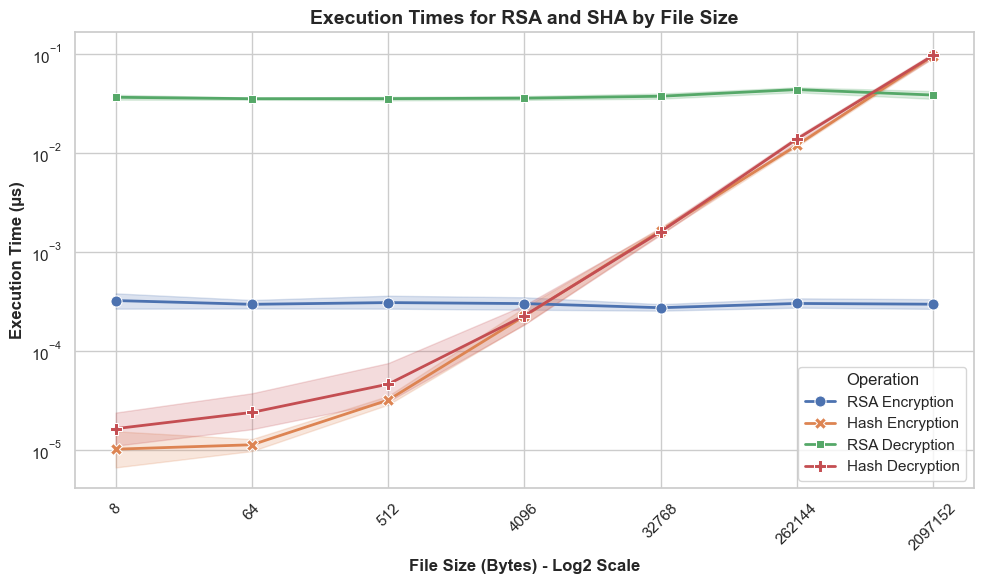

In [20]:
plot_exec_time_by_file_size(df_data)                                 # Function available in file plot_functions.py

&emsp;From this graph, we can clearly see that the RSA functions, both for encrypting and decrypting, do not depend on the file size or content; they are constant, since we use the number "r" for all of them, with the fixed size of 256 bytes.<br>
&emsp;Regarding the time difference between the encrypting and decrypting of the execution times for both RSA encryption and decryption, the process to decrypt the number "r" takes a lot more computational power because the exponent used is the value "d" of the private key (this number usually takes 256 bytes), while the encryption of the number "r" uses an exponent that is represented in only 3 bytes. <br>
&emsp;This time difference is the brilliance of the RSA function, while it's easy to encrypt a message using an public exponent, it will be almost impossible to anyone who doesn't know the exponent from private key decrypt de message. <br>
&emsp;For SHA-256 hashing, the situation is different. The execution time of this hash function scales with the message size. For larger files, the data is partitioned into a higher number of blocks. This requires iterating the hash function over more blocks, which increases the total execution time. However, since the time required to process each individual block is essentially the same, we can conclude that the actual content of the file does not affect the time it takes to hash it.

---

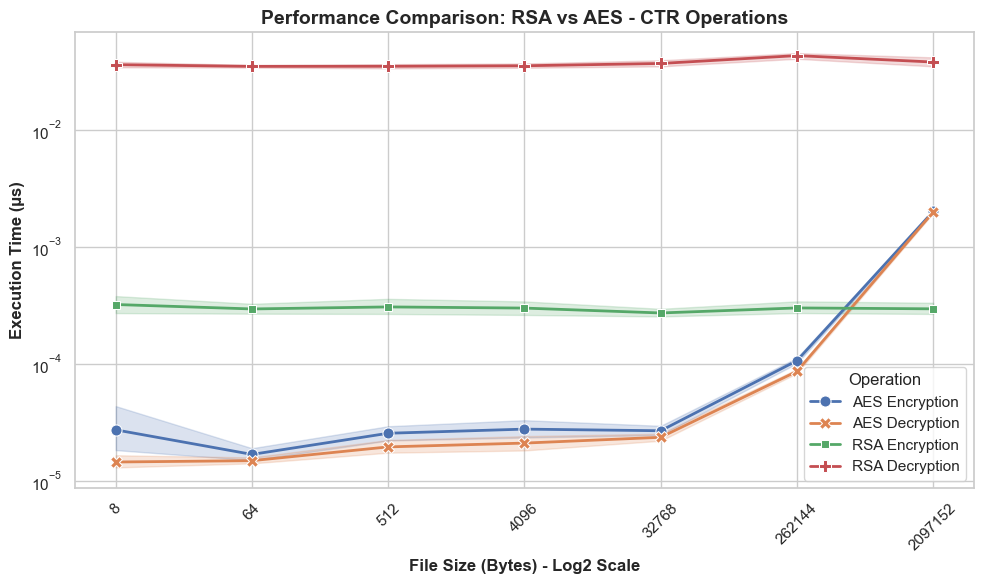

In [21]:
df_RSA = df_data[df_data['Operation'].str.startswith("R")]
plot_comparison_AES_RSA(df_AES, df_RSA)                              # Function available in file plot_functions.py

&emsp;From this graph, we can clearly see the differences between symmetric and asymmetric encryption. While the RSA algorithm relies on complex mathematical equations to encrypt data, the AES algorithm uses bit-oriented operations. Additionally, many modern processors feature dedicated hardware components to accelerate AES encryption.<br>
&emsp;It would take a file more than 1,024 times larger (262,144 bytes) for AES encryption to become slower than the time it takes RSA to encrypt a 256-byte file.<br>
&emsp;The mathematical nature of the RSA algorithm also accounts for the time difference between its encryption and decryption operations. We do not observe this disparity with AES because decryption simply reverses the steps taken during encryption, resulting in nearly identical execution times for both processes.<br>

---

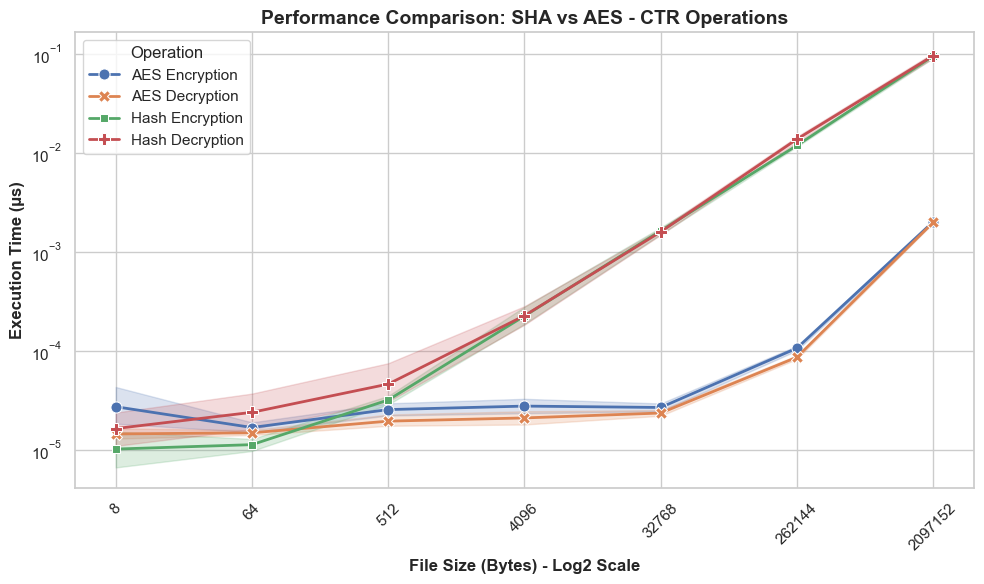

In [22]:
df_SHA = df_data[df_data['Operation'].str.startswith("H")]
plot_comparison_AES_SHA(df_AES, df_SHA)                              # Function available in file plot_functions.py

&emsp;When analyzing the processing time of the SHA-256 hash function compared to AES symmetric encryption, we can observe that both exhibit linear time growth relative to file size, as they operate by partitioning data into successive blocks. However, on modern architectures, AES frequently demonstrates superior speed due to the integration of dedicated hardware acceleration within processors.<br>
&emsp;While SHA-256 must apply a rigorous series of iterative logical and mathematical operations on 64 bytes blocks, the result is a 32 byte block, to ensure the irreversibility of the hash, AES computes its substitution and permutation matrices almost natively on the CPU. Nevertheless, it is important to note that for small files, the absolute difference in execution time between these two operations is statistically insignificant, as both are resolved within fractions of a millisecond.<br>

---